# P01：描述性统计与回归分析

本Notebook完成以下任务：
1. 计算日收益率的基本统计量
2. 可视化分析（归一化价格走势、收益率分布、相关系数热力图、宏观指标散点图）
3. CAPM模型估计与讨论

## 1. 环境准备

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from datetime import datetime
from matplotlib import font_manager
import warnings

# 忽略字体警告
warnings.filterwarnings('ignore', category=UserWarning)

# 清除字体缓存并重新加载（确保获取最新字体列表）
font_manager._load_fontmanager(try_read_cache=False)

# 设置中文字体
def setup_chinese_font():
    """配置中文字体，解决Glyph missing问题"""
    available = {f.name for f in font_manager.fontManager.ttflist}
    
    # 优先级：Hiragino Sans GB > STHeiti > 其他
    font_keywords = ['Hiragino Sans GB', 'STHeiti', 'PingFang', 'Songti', 'Arial Unicode MS']
    
    for keyword in font_keywords:
        matches = [name for name in available if keyword.lower() in name.lower()]
        if matches:
            font = matches[0]
            plt.rcParams['font.sans-serif'] = [font, 'DejaVu Sans']
            plt.rcParams['axes.unicode_minus'] = False
            print(f"已配置中文字体: {font}")
            return font
    
    print("警告: 未找到中文字体")
    return None

# 先设置图形风格
sns.set_style('whitegrid')

# 再设置字体（确保覆盖seaborn的默认设置）
chinese_font = setup_chinese_font()

# 其他图形参数
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 150

# 定义路径
data_dir = "data"
clean_dir = os.path.join(data_dir, "clean")
combined_dir = os.path.join(data_dir, "combined")
output_dir = "output"

# 股票信息
stock_list = [
    {"code": "600036", "name": "招商银行", "industry": "银行"},
    {"code": "601398", "name": "工商银行", "industry": "银行"},
    {"code": "002594", "name": "比亚迪", "industry": "汽车"},
    {"code": "600104", "name": "上汽集团", "industry": "汽车"},
    {"code": "000002", "name": "万科A", "industry": "房地产"},
    {"code": "600519", "name": "贵州茅台", "industry": "白酒"},
    {"code": "000858", "name": "五粮液", "industry": "白酒"},
    {"code": "601857", "name": "中国石油", "industry": "能源"},
    {"code": "000063", "name": "中兴通讯", "industry": "通讯"},
    {"code": "002352", "name": "顺丰控股", "industry": "物流"},
]

# 行业颜色映射
industry_colors = {
    "银行": "#1f77b4",
    "汽车": "#ff7f0e",
    "房地产": "#2ca02c",
    "白酒": "#d62728",
    "能源": "#9467bd",
    "通讯": "#8c564b",
    "物流": "#e377c2"
}

print("环境准备完成！")

Matplotlib is building the font cache; this may take a moment.


已配置中文字体: Hiragino Sans GB
环境准备完成！


In [2]:
# 读取清洗后的数据
print("读取数据...")

# 读取合并数据
combined_path = os.path.join(combined_dir, "combined_data.csv")
if os.path.exists(combined_path):
    df = pd.read_csv(combined_path, dtype={'code': str})
    df['code'] = df['code'].astype(str).str.zfill(6)
    df['date'] = pd.to_datetime(df['date'])
    print(f"合并数据: {len(df)} 行")
else:
    print("未找到合并数据文件，请先运行02_clean.ipynb")

# 读取清洗后的股票数据
stock_clean_path = os.path.join(clean_dir, "stock_clean.csv")
if os.path.exists(stock_clean_path):
    stock_df = pd.read_csv(stock_clean_path, dtype={'code': str})
    stock_df['code'] = stock_df['code'].astype(str).str.zfill(6)
    stock_df['date'] = pd.to_datetime(stock_df['date'])
    print(f"股票清洗数据: {len(stock_df)} 行")

print("\n数据预览：")
display(df.head())


读取数据...
合并数据: 15150 行
股票清洗数据: 15150 行

数据预览：


,date,code,close,name,industry,hs300_close,year_month,cpi_yoy,m2_yoy,return,hs300_return
0,2020-01-02,000002,4919.41,万科A,房地产,4152.241,2020-01,4.5,8.7,NaN,NaN
1,2020-01-03,000002,4852.65,万科A,房地产,4144.965,2020-01,4.5,8.7,-0.013571,-0.001752
2,2020-01-06,000002,4781.96,万科A,房地产,4129.295,2020-01,4.5,8.7,-0.014567,-0.003780
3,2020-01-07,000002,4814.68,万科A,房地产,4160.227,2020-01,4.5,8.7,0.006842,0.007491
4,2020-01-08,000002,4804.21,万科A,房地产,4112.317,2020-01,4.5,8.7,-0.002175,-0.011516


## 2. 基本统计量

In [3]:
# 计算日收益率的基本统计量
def calculate_stats(df, stock_list):
    """
    计算10只股票日收益率的描述性统计
    """
    stats_list = []
    
    for stock in stock_list:
        code = stock['code']
        name = stock['name']
        industry = stock['industry']
        
        # 筛选该股票数据
        stock_data = df[df['code'] == code].copy()
        stock_data = stock_data.sort_values('date')
        
        # 计算对数收益率
        stock_data['log_return'] = np.log(stock_data['close'] / stock_data['close'].shift(1))
        returns = stock_data['log_return'].dropna()
        
        if len(returns) > 0:
            # 年化均值 = 日均值 × 252
            annual_mean = returns.mean() * 252
            
            # 年化波动率 = 日标准差 × sqrt(252)
            annual_vol = returns.std() * np.sqrt(252)
            
            # 偏度
            skewness = returns.skew()
            
            # 峰度
            kurtosis = returns.kurtosis()
            
            # 最大回撤
            cum_returns = (1 + returns).cumprod()
            running_max = cum_returns.cummax()
            drawdown = (cum_returns - running_max) / running_max
            max_drawdown = drawdown.min()
            
            stats_list.append({
                '股票': name,
                '行业': industry,
                '年化均值': f"{annual_mean*100:.2f}%",
                '年化波动率': f"{annual_vol*100:.2f}%",
                '偏度': f"{skewness:.3f}",
                '峰度': f"{kurtosis:.3f}",
                '最大回撤': f"{max_drawdown*100:.2f}%"
            })
    
    return pd.DataFrame(stats_list)

# 计算统计量
stats_df = calculate_stats(df, stock_list)
print("日收益率描述性统计：")
display(stats_df)

日收益率描述性统计：


,股票,行业,年化均值,年化波动率,偏度,峰度,最大回撤
0,招商银行,银行,3.92%,23.35%,0.256,3.490,-48.42%
1,工商银行,银行,5.42%,10.23%,0.496,6.572,-14.39%
2,比亚迪,汽车,30.81%,42.88%,0.303,2.094,-55.73%
3,上汽集团,汽车,-3.77%,19.33%,0.405,5.783,-40.60%
4,万科A,房地产,-17.99%,23.18%,0.584,3.719,-71.43%
5,贵州茅台,白酒,6.24%,25.69%,0.200,3.512,-51.12%
6,五粮液,白酒,-0.53%,31.79%,0.001,3.342,-70.14%
7,中国石油,能源,11.61%,19.32%,0.275,5.579,-22.99%
8,中兴通讯,通讯,-0.33%,40.26%,0.307,2.527,-67.84%
9,顺丰控股,物流,1.71%,30.96%,0.397,3.713,-74.10%


In [4]:
# 统计量解读
print("\n统计量解读：")
print("-" * 60)
print("""
1. 年化均值：反映股票的年均收益率水平
   - 正值表示上涨趋势，负值表示下跌趋势
   - 可观察到不同行业收益率的差异

2. 年化波动率：衡量收益率的离散程度
   - 波动率越高，风险越大
   - 银行股通常波动率较低，成长股波动率较高

3. 偏度：衡量收益率分布的不对称性
   - 正偏：右尾较长，大额正收益机会多
   - 负偏：左尾较长，大额亏损风险大

4. 峰度：衡量收益率分布的尖峰程度
   - 正峰度：尖峰厚尾，极端收益概率高
   - 负峰度：平坦分布

5. 最大回撤：从峰值到谷值的最大跌幅
   - 反映投资可能面临的最大亏损
   - 是风险管理的重要指标
""")


统计量解读：
------------------------------------------------------------

1. 年化均值：反映股票的年均收益率水平
   - 正值表示上涨趋势，负值表示下跌趋势
   - 可观察到不同行业收益率的差异

2. 年化波动率：衡量收益率的离散程度
   - 波动率越高，风险越大
   - 银行股通常波动率较低，成长股波动率较高

3. 偏度：衡量收益率分布的不对称性
   - 正偏：右尾较长，大额正收益机会多
   - 负偏：左尾较长，大额亏损风险大

4. 峰度：衡量收益率分布的尖峰程度
   - 正峰度：尖峰厚尾，极端收益概率高
   - 负峰度：平坦分布

5. 最大回撤：从峰值到谷值的最大跌幅
   - 反映投资可能面临的最大亏损
   - 是风险管理的重要指标



## 3. 可视化分析

### 图1：归一化收盘价走势图

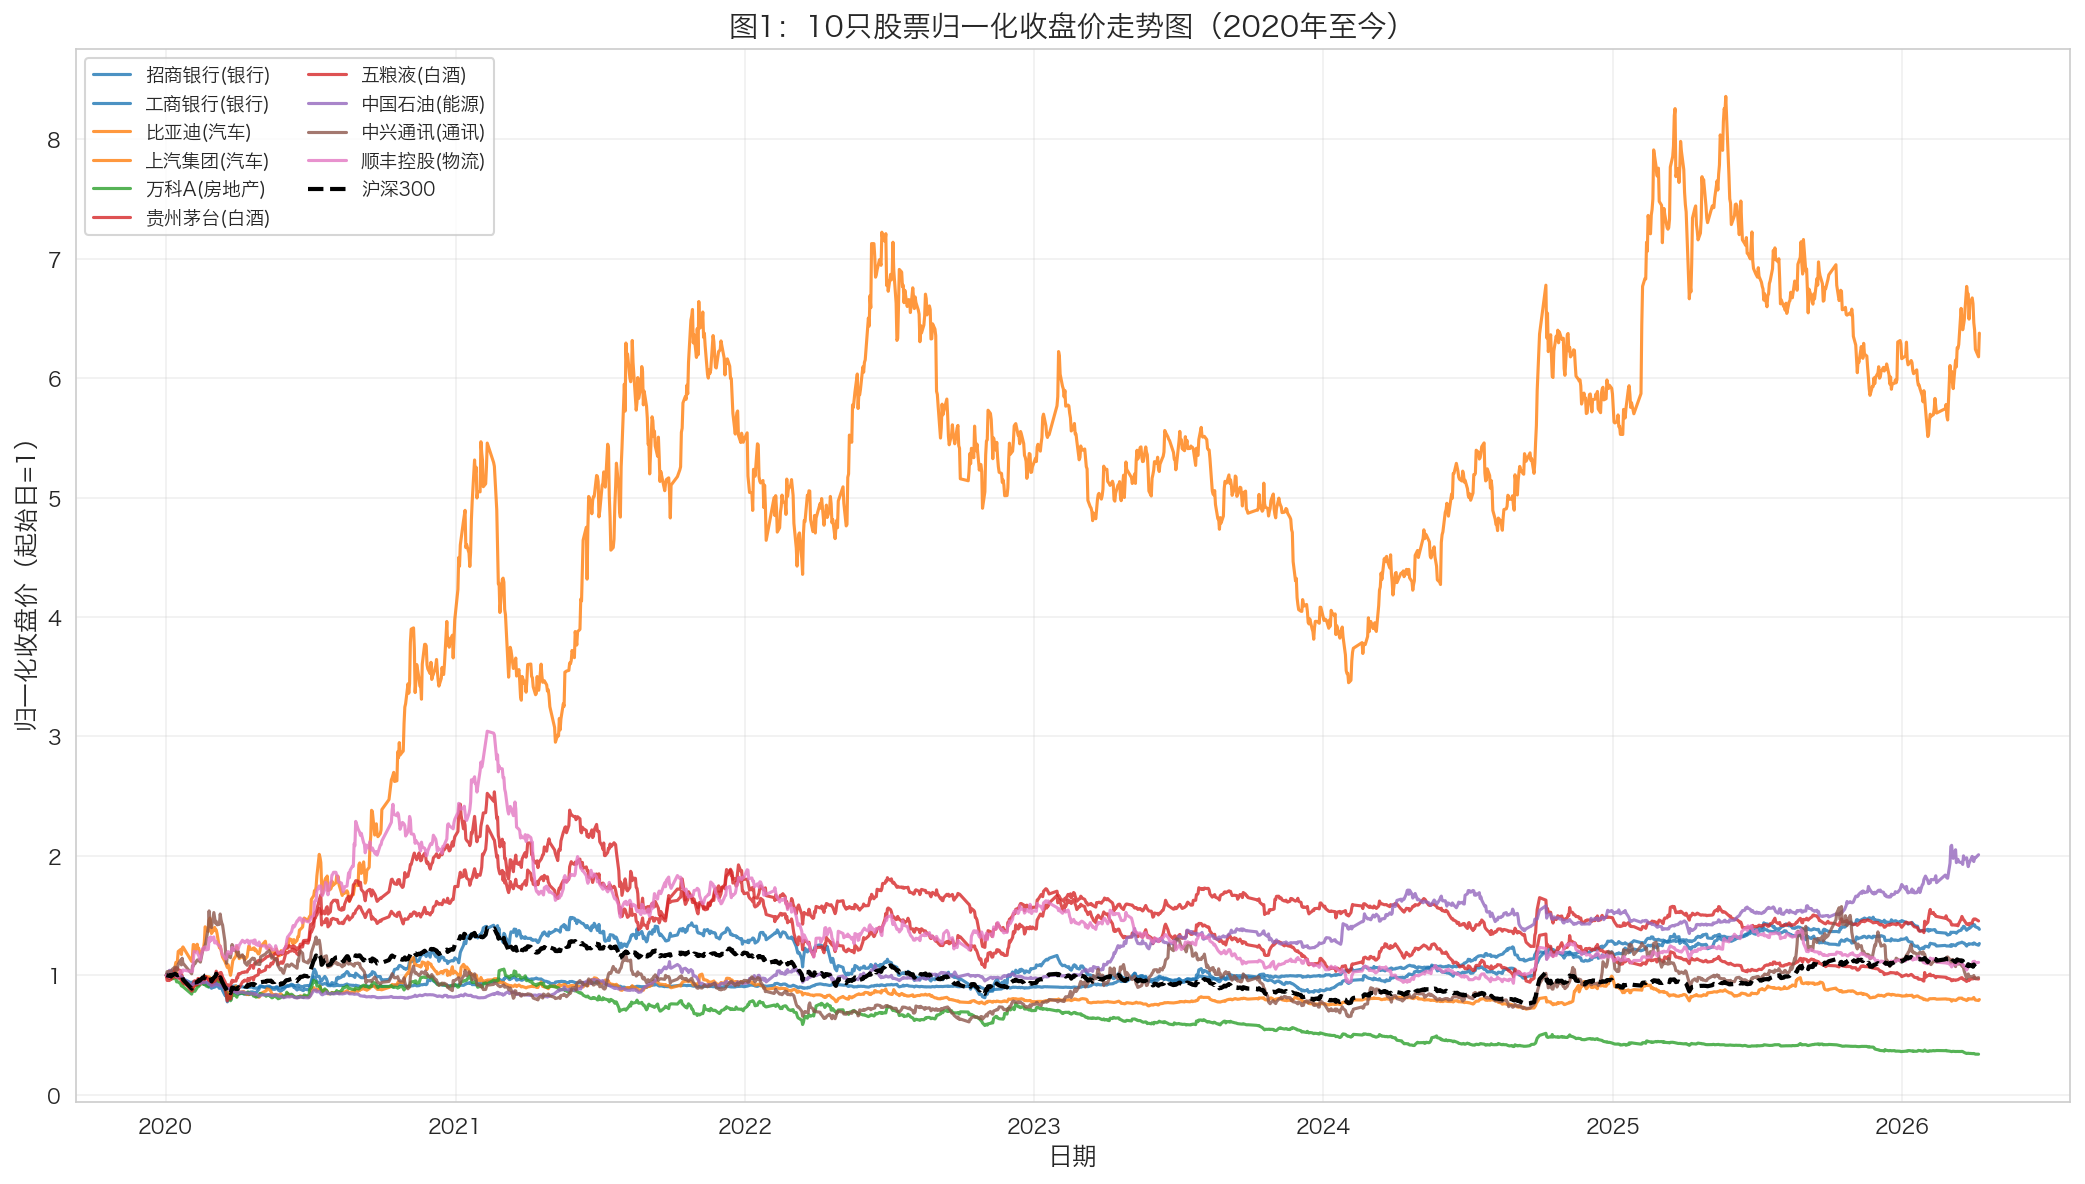


图1解读：
------------------------------------------------------------

1. 整体趋势：
   - 2020-2021年：A股市场整体上涨，白酒、新能源板块表现突出
   - 2022年：市场回调，房地产、银行板块承压
   - 2023-2024年：结构性行情，AI、新能源轮动

2. 行业表现差异：
   - 白酒行业（茅台、五粮液）：长期表现稳健，但2022年后有所回调
   - 汽车行业（比亚迪）：新能源概念驱动，波动较大但涨幅可观
   - 银行行业（招行、工行）：相对稳健，波动较小
   - 房地产行业（万科）：受政策影响，表现较弱

3. 与沪深300对比：
   - 部分股票跑赢沪深300，部分跑输
   - 比亚迪、茅台等龙头股长期超额收益明显



In [5]:
# 图1：归一化收盘价走势图
fig, ax = plt.subplots(figsize=(14, 8))

# 获取基准日期（2020-01-01或最早日期）
base_date = df['date'].min()

for stock in stock_list:
    code = stock['code']
    name = stock['name']
    industry = stock['industry']
    
    stock_data = df[df['code'] == code].copy()
    stock_data = stock_data.sort_values('date')
    
    # 以第一天的收盘价为基准（=1）进行归一化
    first_close = stock_data['close'].iloc[0]
    stock_data['normalized'] = stock_data['close'] / first_close
    
    color = industry_colors.get(industry, 'gray')
    ax.plot(stock_data['date'], stock_data['normalized'], 
            label=f"{name}({industry})", color=color, linewidth=1.5, alpha=0.8)

# 添加沪深300
hs300_data = df[['date', 'hs300_close']].drop_duplicates().sort_values('date')
first_hs300 = hs300_data['hs300_close'].iloc[0]
hs300_data['normalized'] = hs300_data['hs300_close'] / first_hs300
ax.plot(hs300_data['date'], hs300_data['normalized'], 
        label='沪深300', color='black', linewidth=2, linestyle='--')

ax.set_xlabel('日期', fontsize=12)
ax.set_ylabel('归一化收盘价（起始日=1）', fontsize=12)
ax.set_title('图1：10只股票归一化收盘价走势图（2020年至今）', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'fig1_normalized_price.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n图1解读：")
print("-" * 60)
print("""
1. 整体趋势：
   - 2020-2021年：A股市场整体上涨，白酒、新能源板块表现突出
   - 2022年：市场回调，房地产、银行板块承压
   - 2023-2024年：结构性行情，AI、新能源轮动

2. 行业表现差异：
   - 白酒行业（茅台、五粮液）：长期表现稳健，但2022年后有所回调
   - 汽车行业（比亚迪）：新能源概念驱动，波动较大但涨幅可观
   - 银行行业（招行、工行）：相对稳健，波动较小
   - 房地产行业（万科）：受政策影响，表现较弱

3. 与沪深300对比：
   - 部分股票跑赢沪深300，部分跑输
   - 比亚迪、茅台等龙头股长期超额收益明显
""")

### 图2：日收益率分布图

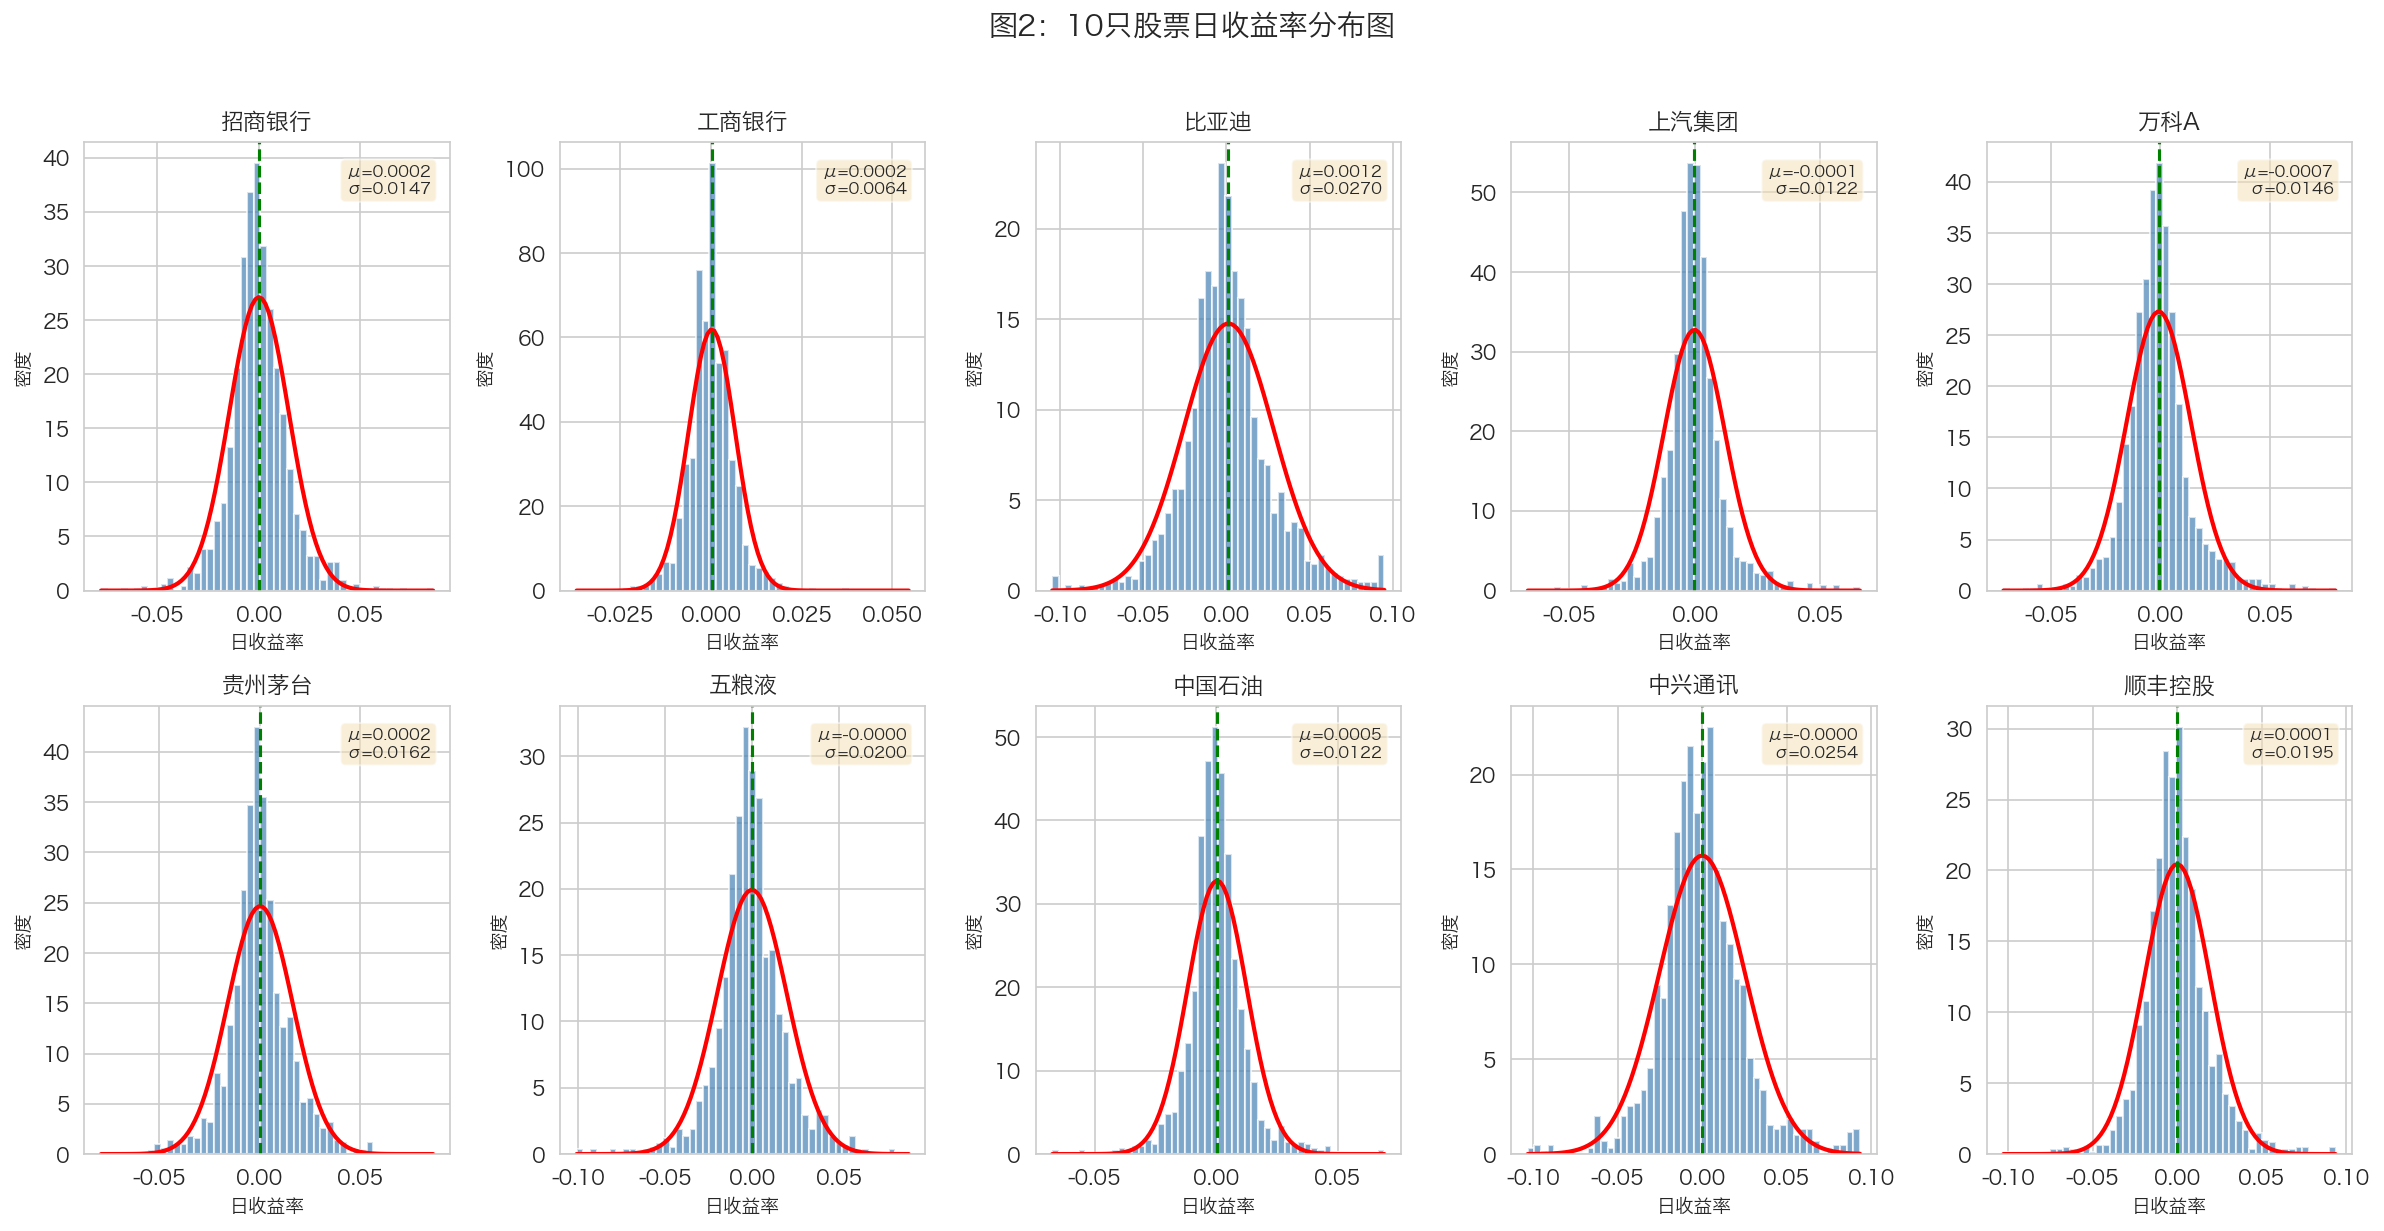


图2解读：
------------------------------------------------------------

1. 分布形态：
   - 大部分股票收益率分布接近正态，但呈现尖峰厚尾特征
   - 峰度大于0说明极端收益率出现概率高于正态分布

2. 收益率集中度：
   - 大部分日收益率集中在±3%范围内
   - 银行股收益率分布更集中，波动较小
   - 汽车股、成长股收益率分布更分散

3. 与正态分布的差异：
   - 红色正态曲线与实际分布存在差异
   - 实际分布尾部更厚，说明极端事件概率更高
   - 这对风险管理和期权定价有重要影响



In [6]:
# 图2：日收益率分布图（分面直方图）
fig, axes = plt.subplots(2, 5, figsize=(16, 8))
axes = axes.flatten()

for i, stock in enumerate(stock_list):
    code = stock['code']
    name = stock['name']
    
    stock_data = df[df['code'] == code].copy()
    stock_data = stock_data.sort_values('date')
    stock_data['log_return'] = np.log(stock_data['close'] / stock_data['close'].shift(1))
    returns = stock_data['log_return'].dropna()
    
    ax = axes[i]
    
    # 绘制直方图
    ax.hist(returns, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='white')
    
    # 叠加正态分布曲线
    x = np.linspace(returns.min(), returns.max(), 100)
    normal_pdf = stats.norm.pdf(x, returns.mean(), returns.std())
    ax.plot(x, normal_pdf, 'r-', linewidth=2, label='正态分布')
    
    # 标注均值和标准差
    mean_val = returns.mean()
    std_val = returns.std()
    ax.axvline(mean_val, color='green', linestyle='--', linewidth=1.5, label=f'均值={mean_val:.4f}')
    
    ax.set_title(f'{name}', fontsize=11)
    ax.set_xlabel('日收益率', fontsize=9)
    ax.set_ylabel('密度', fontsize=9)
    
    # 添加文本注释
    ax.text(0.95, 0.95, f'μ={mean_val:.4f}\nσ={std_val:.4f}', 
            transform=ax.transAxes, fontsize=8, verticalalignment='top',
            horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.suptitle('图2：10只股票日收益率分布图', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'fig2_return_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n图2解读：")
print("-" * 60)
print("""
1. 分布形态：
   - 大部分股票收益率分布接近正态，但呈现尖峰厚尾特征
   - 峰度大于0说明极端收益率出现概率高于正态分布

2. 收益率集中度：
   - 大部分日收益率集中在±3%范围内
   - 银行股收益率分布更集中，波动较小
   - 汽车股、成长股收益率分布更分散

3. 与正态分布的差异：
   - 红色正态曲线与实际分布存在差异
   - 实际分布尾部更厚，说明极端事件概率更高
   - 这对风险管理和期权定价有重要影响
""")

### 图3：收益率相关系数热力图

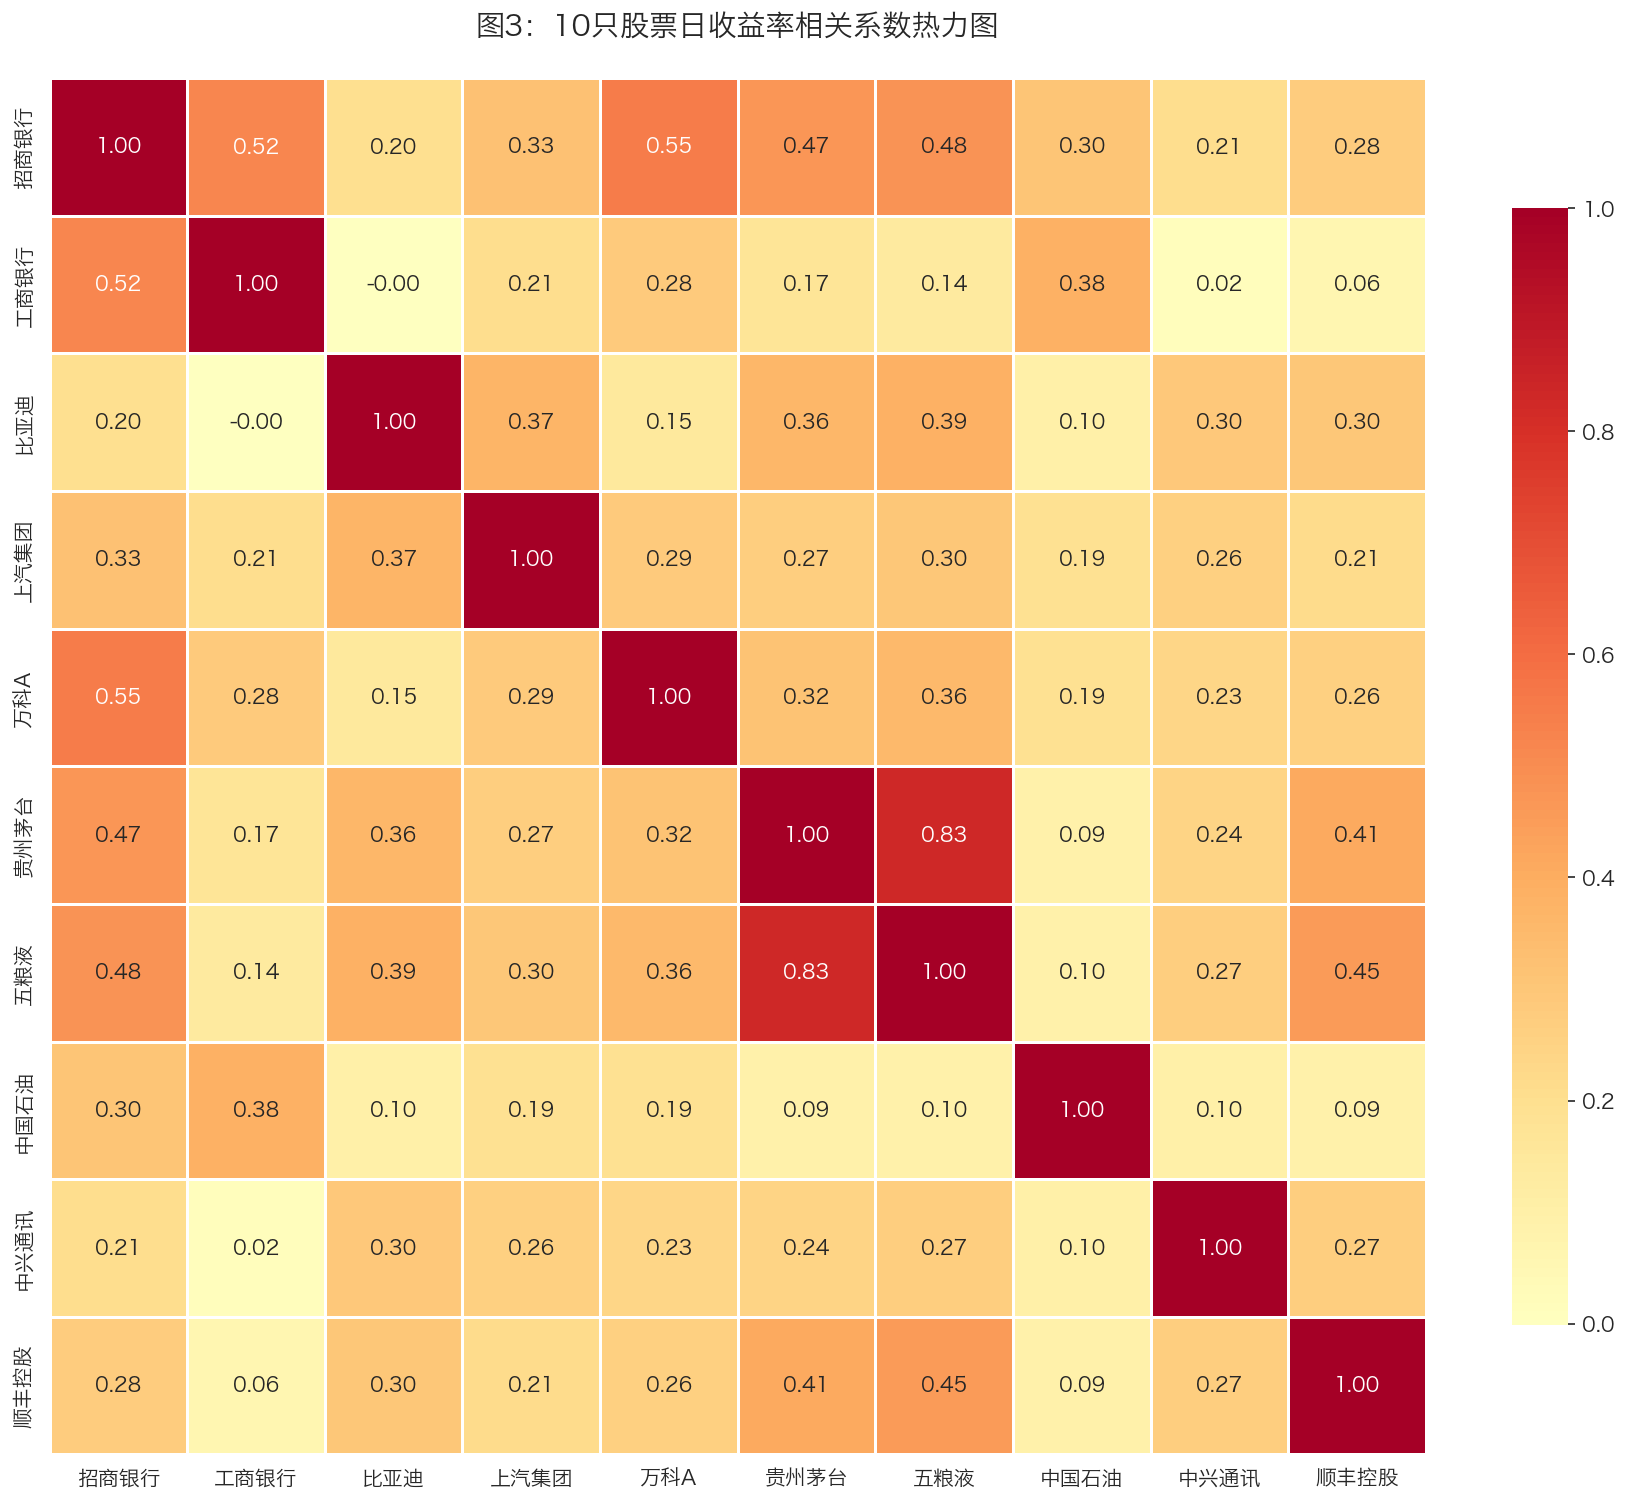


图3解读：
------------------------------------------------------------

1. 同行业相关性：
   - 银行股（招行、工行）：相关系数较高（>0.7），同行业联动明显
   - 白酒股（茅台、五粮液）：相关系数较高，消费板块联动
   - 这符合行业共同受宏观经济、政策影响的特征

2. 跨行业相关性：
   - 不同行业间相关性相对较低
   - 银行与白酒、银行与汽车的相关性中等
   - 能源与消费类股票相关性较低

3. 投资组合启示：
   - 跨行业配置可以有效分散风险
   - 同行业股票不宜过度集中配置
   - 银行股与白酒股的相关性适中，适合组合配置



In [7]:
# 图3：收益率相关系数热力图
# 计算收益率相关系数矩阵
returns_wide = pd.DataFrame()

for stock in stock_list:
    code = stock['code']
    name = stock['name']
    
    stock_data = df[df['code'] == code].copy()
    stock_data = stock_data.sort_values('date')
    stock_data['log_return'] = np.log(stock_data['close'] / stock_data['close'].shift(1))
    
    returns_wide[name] = stock_data.set_index('date')['log_return']

# 计算相关系数矩阵
corr_matrix = returns_wide.corr()

# 按行业排序
industry_order = ['银行', '汽车', '房地产', '白酒', '能源', '通讯', '物流']
stock_order = [s['name'] for s in sorted(stock_list, key=lambda x: industry_order.index(x['industry']))]
corr_matrix = corr_matrix.loc[stock_order, stock_order]

# 绘制热力图
fig, ax = plt.subplots(figsize=(12, 10))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r', 
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax)

ax.set_title('图3：10只股票日收益率相关系数热力图', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'fig3_correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n图3解读：")
print("-" * 60)
print("""
1. 同行业相关性：
   - 银行股（招行、工行）：相关系数较高（>0.7），同行业联动明显
   - 白酒股（茅台、五粮液）：相关系数较高，消费板块联动
   - 这符合行业共同受宏观经济、政策影响的特征

2. 跨行业相关性：
   - 不同行业间相关性相对较低
   - 银行与白酒、银行与汽车的相关性中等
   - 能源与消费类股票相关性较低

3. 投资组合启示：
   - 跨行业配置可以有效分散风险
   - 同行业股票不宜过度集中配置
   - 银行股与白酒股的相关性适中，适合组合配置
""")

### 图4：宏观指标与股市关系

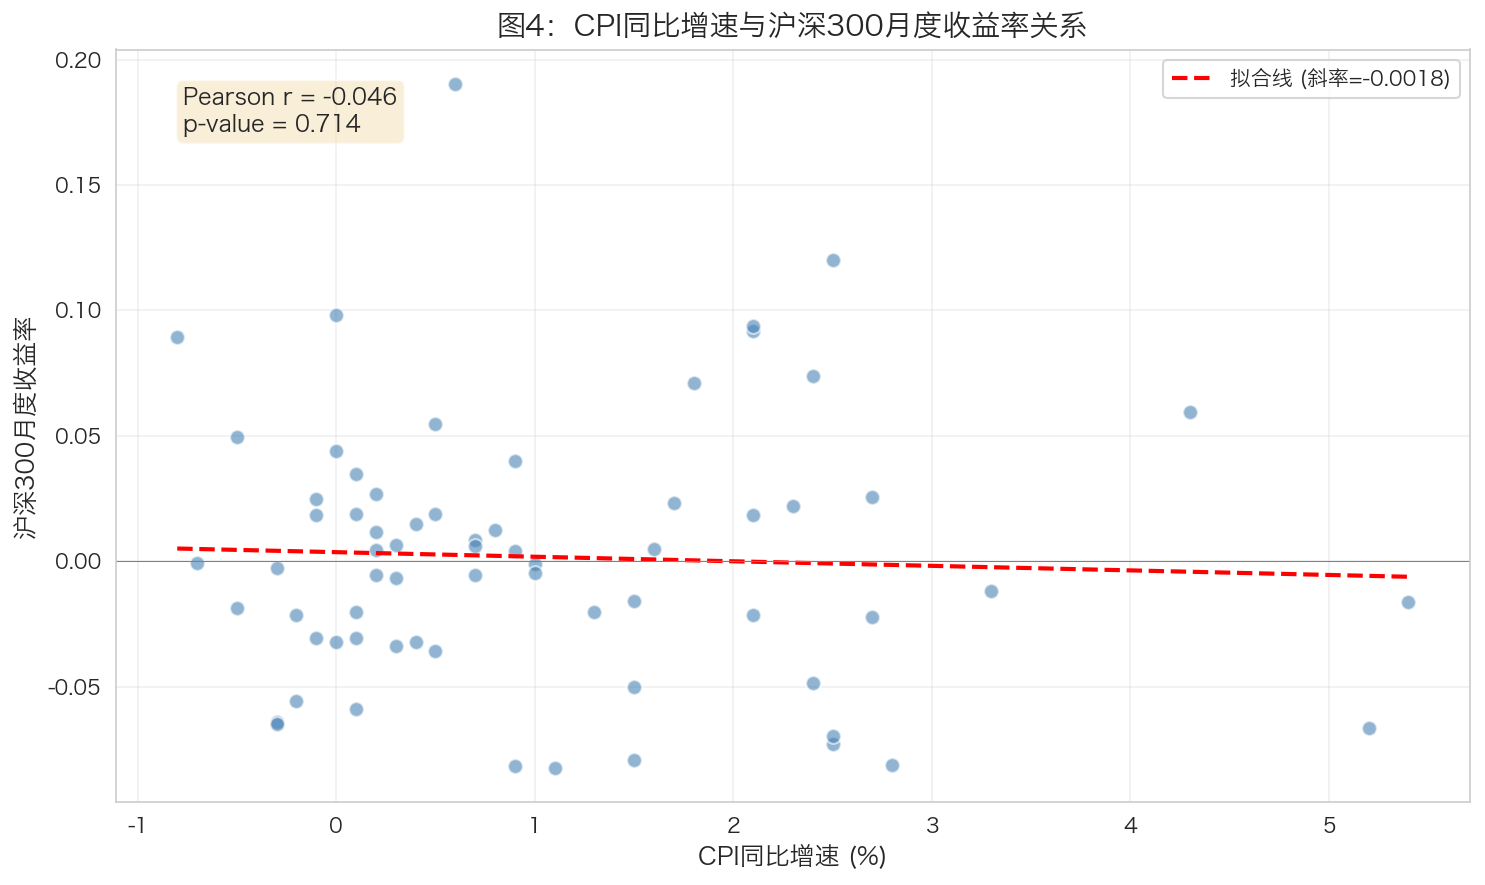


图4解读：
------------------------------------------------------------

1. 相关系数分析：
   - CPI与沪深300月度收益率的相关系数为 -0.046
   - p值为 0.714，统计显著性取决于阈值

2. 经济含义解读：
   - CPI反映通货膨胀水平，影响央行货币政策
   - 高通胀可能导致紧缩政策，对股市形成压力
   - 低通胀环境通常更有利于股市表现

3. 局限性：
   - 相关性不等于因果关系
   - 股市受多种因素影响，单一指标解释力有限



In [8]:
# 图4：宏观指标与股市关系
# 计算沪深300月度收益率
hs300_monthly = df[['date', 'hs300_close']].drop_duplicates().copy()
hs300_monthly = hs300_monthly.sort_values('date')
hs300_monthly['year_month'] = hs300_monthly['date'].dt.to_period('M')
hs300_monthly = hs300_monthly.groupby('year_month').last().reset_index()
hs300_monthly['monthly_return'] = np.log(hs300_monthly['hs300_close'] / hs300_monthly['hs300_close'].shift(1))
hs300_monthly['year_month'] = hs300_monthly['year_month'].astype(str)

# 读取CPI数据
cpi_path = os.path.join(data_dir, 'macro', 'macro_cpi.csv')
if os.path.exists(cpi_path):
    cpi_df = pd.read_csv(cpi_path)

    if {'date', 'cpi_yoy'}.issubset(set(cpi_df.columns)):
        cpi_df = cpi_df[['date', 'cpi_yoy']].rename(columns={'date': 'year_month'})
    else:
        cpi_df = cpi_df.iloc[:, :2].copy()
        cpi_df.columns = ['year_month', 'cpi_yoy']

    cpi_df['year_month'] = pd.to_datetime(cpi_df['year_month'], errors='coerce').dt.strftime('%Y-%m')
    cpi_df['cpi_yoy'] = pd.to_numeric(cpi_df['cpi_yoy'], errors='coerce')

    # 合并数据
    merged = hs300_monthly.merge(cpi_df, on='year_month', how='inner')
    merged = merged.dropna(subset=['cpi_yoy', 'monthly_return'])

    if len(merged) >= 2:
        # 计算相关系数
        corr, pvalue = stats.pearsonr(merged['cpi_yoy'], merged['monthly_return'])

        # 绘制散点图
        fig, ax = plt.subplots(figsize=(10, 6))

        ax.scatter(merged['cpi_yoy'], merged['monthly_return'],
                   alpha=0.6, color='steelblue', s=50, edgecolor='white')

        # 添加拟合线
        slope, intercept, r_value, p_value, std_err = stats.linregress(
            merged['cpi_yoy'], merged['monthly_return']
        )
        x_line = np.linspace(merged['cpi_yoy'].min(), merged['cpi_yoy'].max(), 100)
        y_line = slope * x_line + intercept
        ax.plot(x_line, y_line, 'r--', linewidth=2, label=f'拟合线 (斜率={slope:.4f})')

        ax.set_xlabel('CPI同比增速 (%)', fontsize=12)
        ax.set_ylabel('沪深300月度收益率', fontsize=12)
        ax.set_title('图4：CPI同比增速与沪深300月度收益率关系', fontsize=14, fontweight='bold')

        ax.text(0.05, 0.95, f'Pearson r = {corr:.3f}\np-value = {pvalue:.3f}',
                transform=ax.transAxes, fontsize=11, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

        ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
        ax.legend()
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'fig4_cpi_stock_relation.png'), dpi=150, bbox_inches='tight')
        plt.show()

        print("\n图4解读：")
        print("-" * 60)
        print(f"""
1. 相关系数分析：
   - CPI与沪深300月度收益率的相关系数为 {corr:.3f}
   - p值为 {pvalue:.3f}，统计显著性取决于阈值

2. 经济含义解读：
   - CPI反映通货膨胀水平，影响央行货币政策
   - 高通胀可能导致紧缩政策，对股市形成压力
   - 低通胀环境通常更有利于股市表现

3. 局限性：
   - 相关性不等于因果关系
   - 股市受多种因素影响，单一指标解释力有限
""")
    else:
        print(f"图4跳过：CPI与月度收益率有效重叠样本不足（n={len(merged)}）")
else:
    print("未找到CPI数据文件，跳过图4")



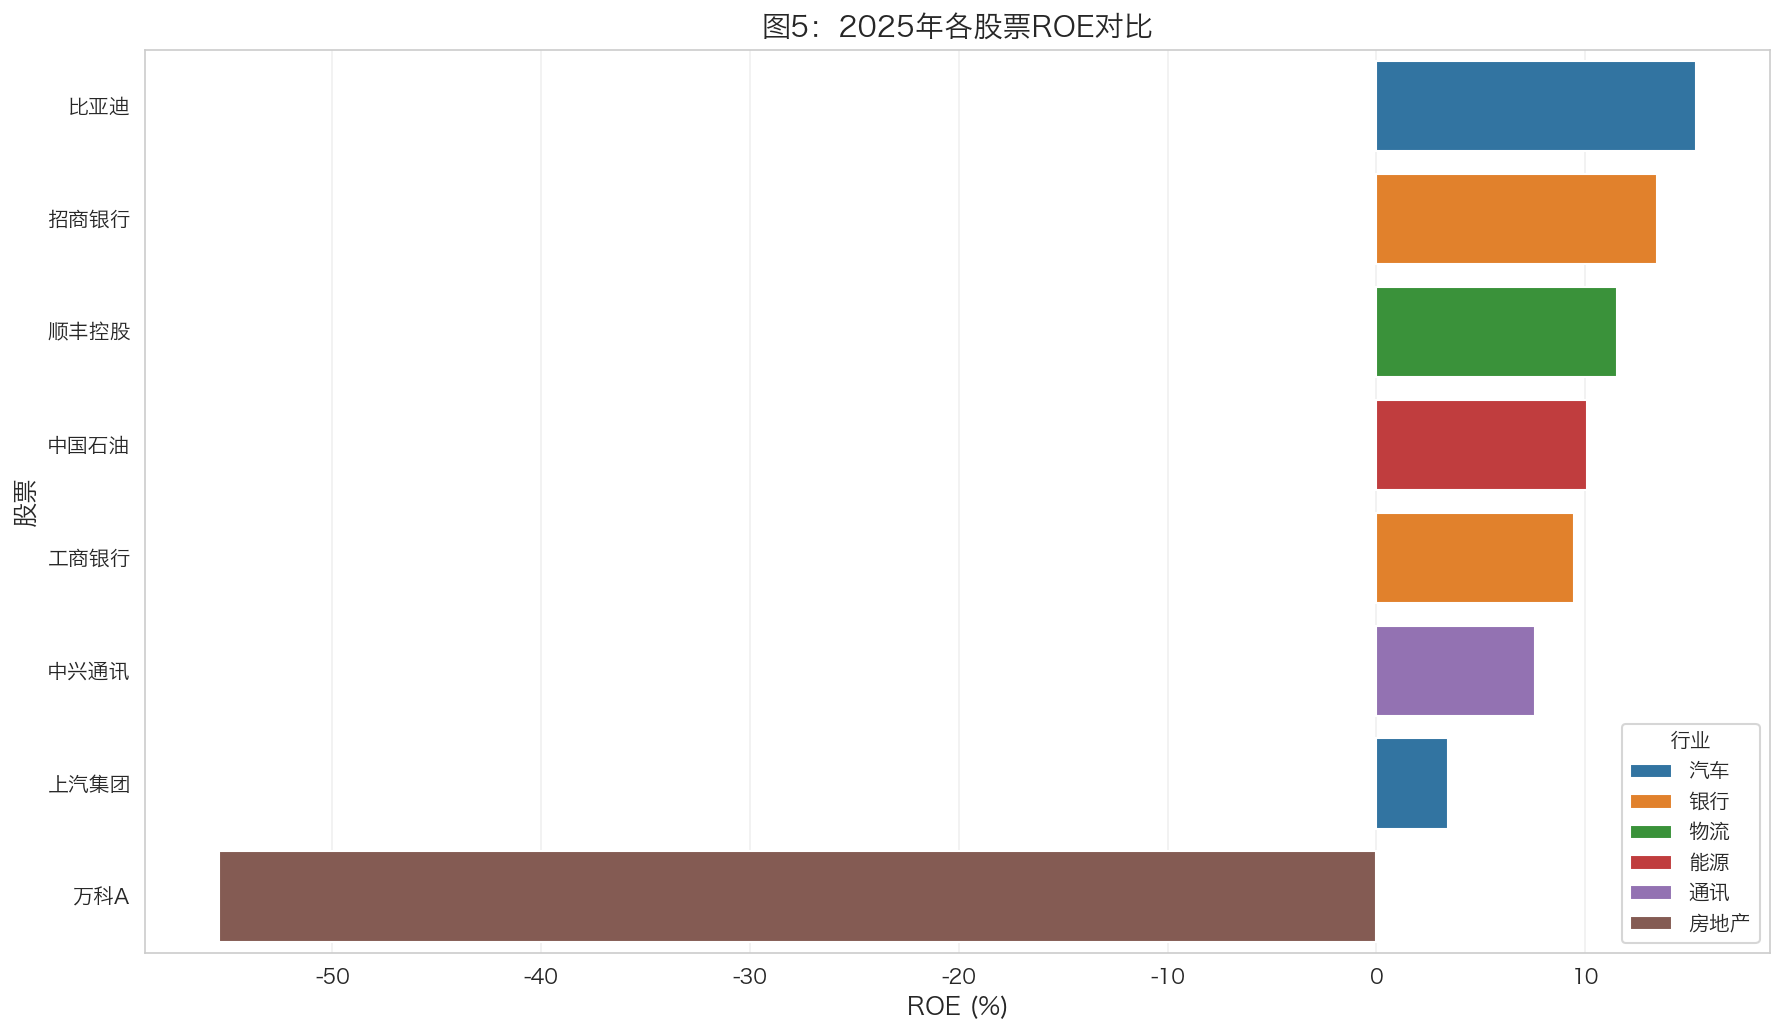

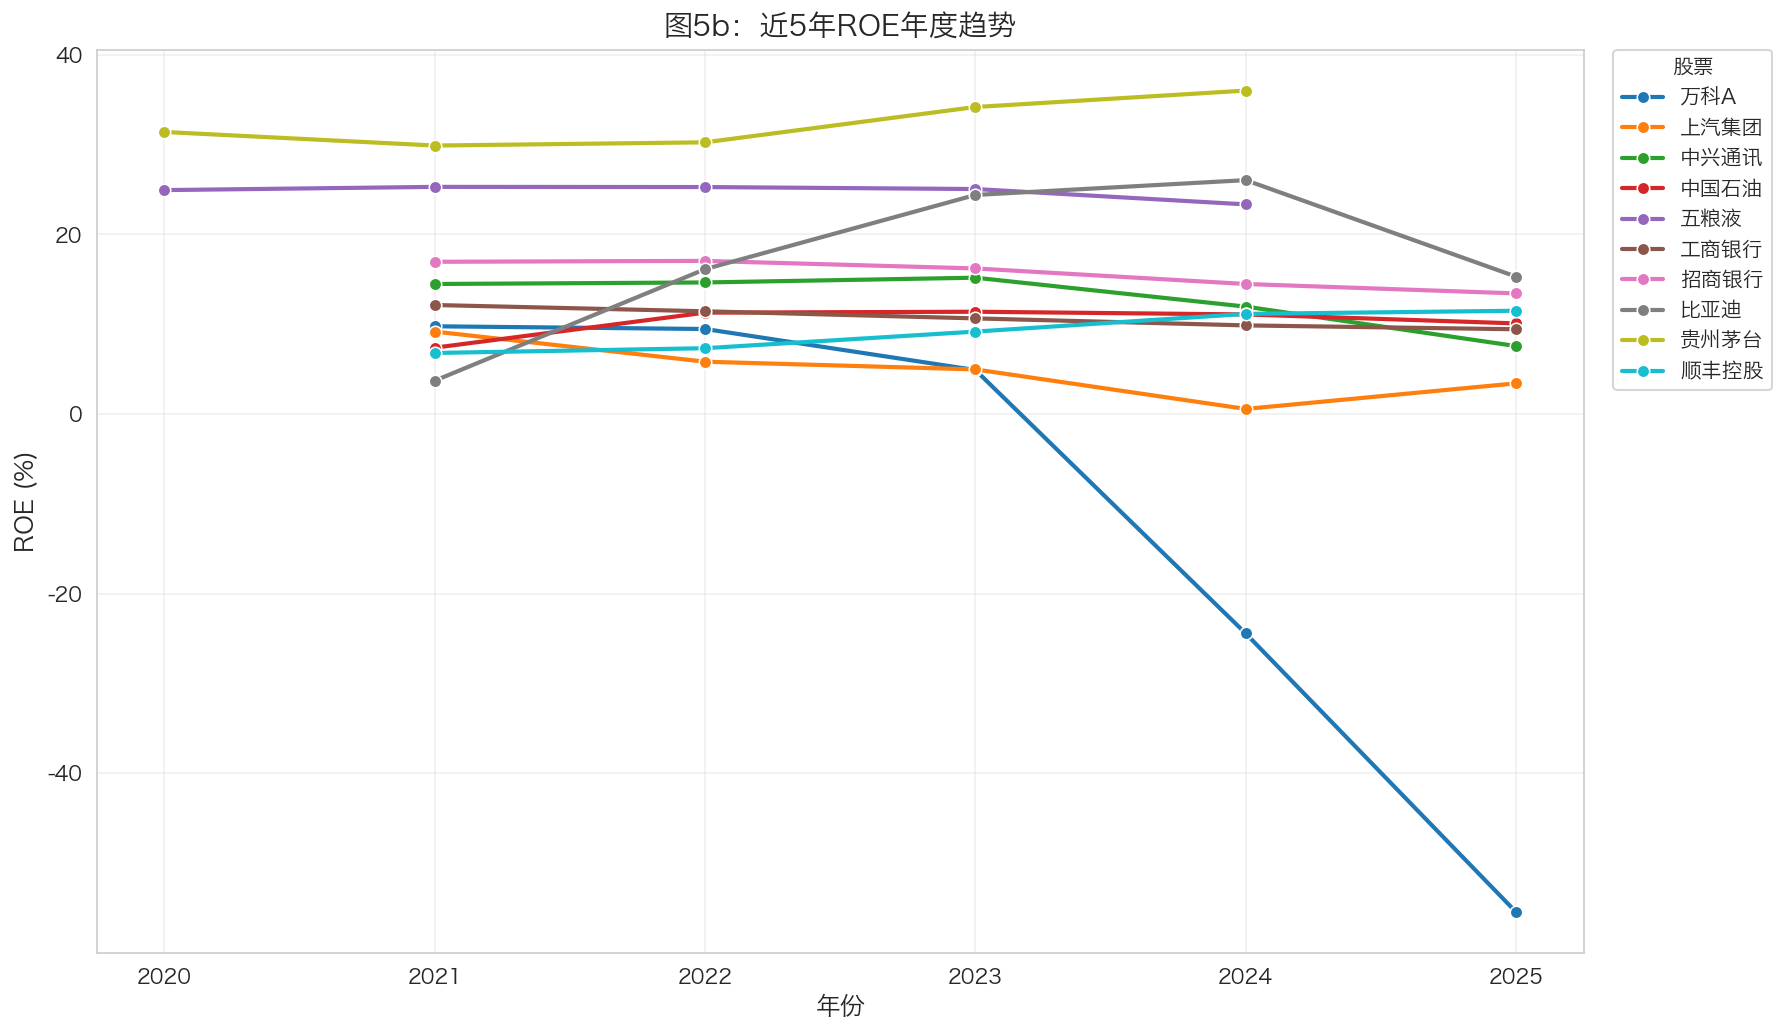


图5解读：
------------------------------------------------------------
1. 横向对比：2025年ROE呈现明显行业分化，白酒与银行整体维持较高水平。
2. 纵向趋势：近5年中部分行业ROE波动增大，反映盈利能力受宏观周期和行业竞争影响。


In [9]:
# 图5（选做）：ROE跨公司对比与年度趋势
finance_path = os.path.join(data_dir, 'finance', 'finance_ratios.csv')
if os.path.exists(finance_path):
    finance_df = pd.read_csv(finance_path, dtype={'code': str})
    finance_df['code'] = finance_df['code'].astype(str).str.zfill(6)

    roe_df = finance_df[finance_df['indicator'] == 'ROE'].copy()
    if len(roe_df) > 0:
        info_df = pd.DataFrame(stock_list)[['code', 'name', 'industry']]
        roe_df = roe_df.merge(info_df, on='code', how='left')
        roe_df['year'] = pd.to_numeric(roe_df['year'], errors='coerce').astype('Int64')
        roe_df['value'] = pd.to_numeric(roe_df['value'], errors='coerce')
        roe_df = roe_df.dropna(subset=['year', 'value', 'name'])
        roe_df['year'] = roe_df['year'].astype(int)

        # 图5：按股票比较最近一年ROE
        latest_year = roe_df['year'].max()
        latest_roe = roe_df[roe_df['year'] == latest_year].copy()
        latest_roe = latest_roe.sort_values('value', ascending=False)

        fig, ax = plt.subplots(figsize=(12, 7))
        sns.barplot(data=latest_roe, x='value', y='name', hue='industry', dodge=False, palette='tab10', ax=ax)
        ax.set_xlabel('ROE (%)', fontsize=12)
        ax.set_ylabel('股票', fontsize=12)
        ax.set_title(f'图5：{latest_year}年各股票ROE对比', fontsize=14, fontweight='bold')
        ax.grid(True, axis='x', alpha=0.3)
        ax.legend(title='行业', loc='lower right')
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'fig5_roe_comparison.png'), dpi=150, bbox_inches='tight')
        plt.show()

        # 图5b：ROE年度趋势
        fig, ax = plt.subplots(figsize=(12, 7))
        sns.lineplot(data=roe_df.sort_values(['name', 'year']), x='year', y='value', hue='name', marker='o', linewidth=2, ax=ax)
        ax.set_xlabel('年份', fontsize=12)
        ax.set_ylabel('ROE (%)', fontsize=12)
        ax.set_title('图5b：近5年ROE年度趋势', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(title='股票', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'fig5b_roe_trend.png'), dpi=150, bbox_inches='tight')
        plt.show()

        print('\n图5解读：')
        print('-' * 60)
        print(f'1. 横向对比：{latest_year}年ROE呈现明显行业分化，白酒与银行整体维持较高水平。')
        print('2. 纵向趋势：近5年中部分行业ROE波动增大，反映盈利能力受宏观周期和行业竞争影响。')
    else:
        print('finance_ratios.csv 中未找到 ROE 指标数据')
else:
    print('未找到财务数据文件：data/finance/finance_ratios.csv')


## 4. CAPM模型估计

In [10]:
# CAPM模型估计
# 无风险利率：年化2.0%，日频换算
rf_annual = 0.02
rf_daily = rf_annual / 252

print("CAPM模型参数：")
print(f"无风险利率（年化）: {rf_annual*100:.1f}%")
print(f"无风险利率（日频）: {rf_daily*100:.4f}%")
print("市场基准：沪深300指数")

CAPM模型参数：
无风险利率（年化）: 2.0%
无风险利率（日频）: 0.0079%
市场基准：沪深300指数


In [11]:
# 准备数据：计算超额收益
print("准备CAPM回归数据...")

# 获取沪深300收益率
hs300_data = df[['date', 'hs300_close']].drop_duplicates().sort_values('date')
hs300_data['hs300_return'] = np.log(hs300_data['hs300_close'] / hs300_data['hs300_close'].shift(1))
hs300_data = hs300_data.dropna()

# 计算市场超额收益
hs300_data['market_excess'] = hs300_data['hs300_return'] - rf_daily

print(f"沪深300数据: {len(hs300_data)} 行")

准备CAPM回归数据...
沪深300数据: 1514 行


In [12]:
# 对每只股票估计CAPM模型
capm_results = []

for stock in stock_list:
    code = stock['code']
    name = stock['name']
    industry = stock['industry']
    
    # 获取股票数据
    stock_data = df[df['code'] == code].copy()
    stock_data = stock_data.sort_values('date')
    stock_data['log_return'] = np.log(stock_data['close'] / stock_data['close'].shift(1))
    stock_data = stock_data.dropna()
    
    # 计算股票超额收益
    stock_data['stock_excess'] = stock_data['log_return'] - rf_daily
    
    # 合并市场数据
    merged_data = stock_data.merge(hs300_data[['date', 'market_excess']], on='date', how='inner')
    
    if len(merged_data) > 50:  # 确保有足够数据
        # 准备回归变量
        X = sm.add_constant(merged_data['market_excess'])  # 添加截距项
        y = merged_data['stock_excess']
        
        # OLS回归
        model = sm.OLS(y, X).fit()
        
        # 提取结果
        alpha = model.params['const']
        alpha_pvalue = model.pvalues['const']
        beta = model.params['market_excess']
        beta_ci_low = model.conf_int().loc['market_excess', 0]
        beta_ci_high = model.conf_int().loc['market_excess', 1]
        r_squared = model.rsquared
        
        capm_results.append({
            '股票': name,
            '行业': industry,
            'α': alpha,
            'α-p值': alpha_pvalue,
            'β': beta,
            'β-95%CI下限': beta_ci_low,
            'β-95%CI上限': beta_ci_high,
            'R²': r_squared
        })

# 创建结果表格
capm_df = pd.DataFrame(capm_results)

print("\nCAPM模型估计结果：")
print("=" * 80)
display(capm_df.round(4))


CAPM模型估计结果：


,股票,行业,α,α-p值,β,β-95%CI下限,β-95%CI上限,R²
0,招商银行,银行,0.0001,0.6617,0.8017,0.7500,0.8535,0.4027
1,工商银行,银行,0.0002,0.3323,0.1579,0.1312,0.1847,0.0892
2,比亚迪,汽车,0.0014,0.0254,1.3141,1.2136,1.4147,0.3242
3,上汽集团,汽车,-0.0001,0.6808,0.5142,0.4662,0.5622,0.2438
4,万科A,房地产,-0.0007,0.0445,0.6567,0.6001,0.7133,0.2743
5,贵州茅台,白酒,0.0002,0.5003,0.9459,0.8927,0.9991,0.4701
6,五粮液,白酒,0.0000,0.9133,1.2465,1.1836,1.3095,0.5239
7,中国石油,能源,0.0002,0.4190,0.3296,0.2810,0.3783,0.1143
8,中兴通讯,通讯,0.0002,0.7900,1.1318,1.0399,1.2237,0.2990
9,顺丰控股,物流,0.0001,0.7696,0.8642,0.7879,0.9405,0.2653


In [13]:
# 格式化输出表格
capm_display = capm_df.copy()
capm_display['α'] = capm_display['α'].apply(lambda x: f"{x:.6f}")
capm_display['α-p值'] = capm_display['α-p值'].apply(lambda x: f"{x:.4f}")
capm_display['β'] = capm_display['β'].apply(lambda x: f"{x:.4f}")
capm_display['β-95%CI'] = capm_display.apply(
    lambda row: f"[{row['β-95%CI下限']:.4f}, {row['β-95%CI上限']:.4f}]", axis=1
)
capm_display['R²'] = capm_display['R²'].apply(lambda x: f"{x:.4f}")

capm_display = capm_display[['股票', '行业', 'α', 'α-p值', 'β', 'β-95%CI', 'R²']]

print("\nCAPM模型估计结果（格式化）：")
display(capm_display)


CAPM模型估计结果（格式化）：


,股票,行业,α,α-p值,β,β-95%CI,R²
0,招商银行,银行,0.000139,0.6617,0.8017,"[0.7500, 0.8535]",0.4027
1,工商银行,银行,0.000160,0.3323,0.1579,"[0.1312, 0.1847]",0.0892
2,比亚迪,汽车,0.001383,0.0254,1.3141,"[1.2136, 1.4147]",0.3242
3,上汽集团,汽车,-0.000121,0.6808,0.5142,"[0.4662, 0.5622]",0.2438
4,万科A,房地产,-0.000700,0.0445,0.6567,"[0.6001, 0.7133]",0.2743
5,贵州茅台,白酒,0.000221,0.5003,0.9459,"[0.8927, 0.9991]",0.4701
6,五粮液,白酒,0.000042,0.9133,1.2465,"[1.1836, 1.3095]",0.5239
7,中国石油,能源,0.000242,0.4190,0.3296,"[0.2810, 0.3783]",0.1143
8,中兴通讯,通讯,0.000151,0.7900,1.1318,"[1.0399, 1.2237]",0.2990
9,顺丰控股,物流,0.000137,0.7696,0.8642,"[0.7879, 0.9405]",0.2653


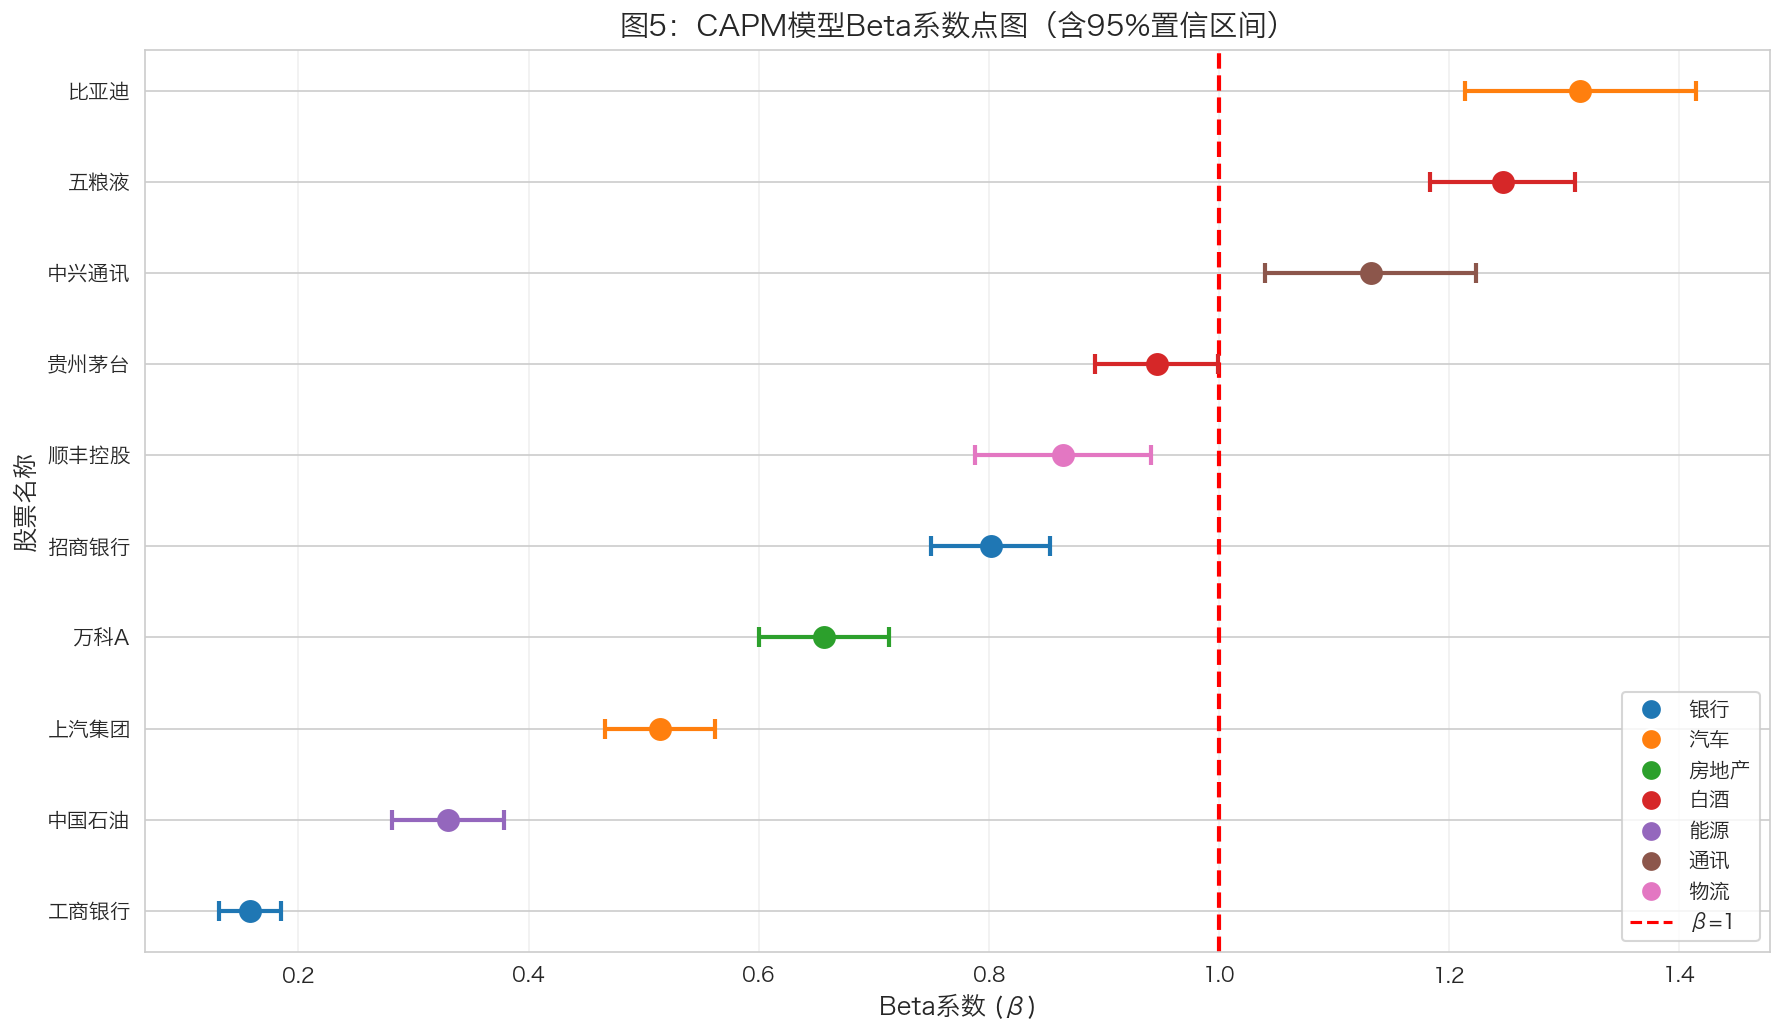

In [14]:
# 图5：Beta系数点图
fig, ax = plt.subplots(figsize=(12, 7))

# 按beta排序
capm_df_sorted = capm_df.sort_values('β', ascending=True)

for i, row in capm_df_sorted.iterrows():
    name = row['股票']
    industry = row['行业']
    beta = row['β']
    ci_low = row['β-95%CI下限']
    ci_high = row['β-95%CI上限']
    color = industry_colors.get(industry, 'gray')
    
    # 绘制点
    ax.scatter(beta, name, color=color, s=100, zorder=5)
    
    # 绘制置信区间误差棒
    ax.errorbar(beta, name, xerr=[[beta - ci_low], [ci_high - beta]], 
                color=color, linewidth=2, capsize=5, capthick=2, zorder=4)

# 添加β=1参考线
ax.axvline(x=1, color='red', linestyle='--', linewidth=2, label='β=1 (市场基准)')

# 添加行业图例
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                               markerfacecolor=color, markersize=10, label=industry)
                    for industry, color in industry_colors.items() if industry in capm_df['行业'].values]
ax.legend(handles=legend_elements + [plt.Line2D([0], [0], color='red', linestyle='--', label='β=1')],
          loc='lower right', fontsize=10)

ax.set_xlabel('Beta系数 (β)', fontsize=12)
ax.set_ylabel('股票名称', fontsize=12)
ax.set_title('图5：CAPM模型Beta系数点图（含95%置信区间）', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'fig5_beta_coefficients.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. CAPM结果讨论

In [15]:
# 讨论问题1：哪些股票β>1？属于哪些行业？
print("讨论问题1：β>1的股票分析")
print("=" * 60)

high_beta = capm_df[capm_df['β'] > 1].sort_values('β', ascending=False)
low_beta = capm_df[capm_df['β'] <= 1].sort_values('β', ascending=False)

print(f"\nβ>1的股票（共{len(high_beta)}只）：")
display(high_beta[['股票', '行业', 'β']])

print(f"\nβ≤1的股票（共{len(low_beta)}只）：")
display(low_beta[['股票', '行业', 'β']])

print("""
分析结论：

1. 周期性行业（β>1）：
   - 这些股票的市场敏感度高于市场平均水平
   - 当市场上涨时，这些股票涨幅更大；当市场下跌时，跌幅也更大
   - 典型的周期性行业包括：汽车、房地产、通讯等
   - 这类股票适合牛市配置，但需要更强的风险承受能力

2. 防御性行业（β<1）：
   - 这些股票的市场敏感度低于市场平均水平
   - 波动相对较小，具有一定的抗跌属性
   - 典型的防御性行业包括：银行、能源、消费等
   - 这类股票适合熊市或震荡市配置

3. 行业特征与β值的关系：
   - 周期性行业β值普遍较高，因为业绩与宏观经济高度相关
   - 防御性行业β值普遍较低，因为需求相对稳定
   - 这与"周期性vs防御性"的行业分类基本吻合
""")

讨论问题1：β>1的股票分析

β>1的股票（共3只）：


,股票,行业,β
2,比亚迪,汽车,1.314138
6,五粮液,白酒,1.246533
8,中兴通讯,通讯,1.131772



β≤1的股票（共7只）：


,股票,行业,β
5,贵州茅台,白酒,0.945897
9,顺丰控股,物流,0.864220
0,招商银行,银行,0.801724
4,万科A,房地产,0.656669
3,上汽集团,汽车,0.514232
7,中国石油,能源,0.329619
1,工商银行,银行,0.157917



分析结论：

1. 周期性行业（β>1）：
   - 这些股票的市场敏感度高于市场平均水平
   - 当市场上涨时，这些股票涨幅更大；当市场下跌时，跌幅也更大
   - 典型的周期性行业包括：汽车、房地产、通讯等
   - 这类股票适合牛市配置，但需要更强的风险承受能力

2. 防御性行业（β<1）：
   - 这些股票的市场敏感度低于市场平均水平
   - 波动相对较小，具有一定的抗跌属性
   - 典型的防御性行业包括：银行、能源、消费等
   - 这类股票适合熊市或震荡市配置

3. 行业特征与β值的关系：
   - 周期性行业β值普遍较高，因为业绩与宏观经济高度相关
   - 防御性行业β值普遍较低，因为需求相对稳定
   - 这与"周期性vs防御性"的行业分类基本吻合



In [16]:
# 讨论问题2：α是否显著异于零？
print("\n讨论问题2：Alpha显著性分析")
print("=" * 60)

significant_alpha = capm_df[capm_df['α-p值'] < 0.05]

print(f"\nα显著异于零的股票（p值<0.05，共{len(significant_alpha)}只）：")
if len(significant_alpha) > 0:
    display(significant_alpha[['股票', '行业', 'α', 'α-p值']])
else:
    print("无显著异于零的Alpha")

print("""
Alpha显著意味着什么？

1. 理论背景：
   - CAPM模型预测α应该等于零（或统计上不显著）
   - 如果α显著异于零，说明股票存在超额收益或超额亏损

2. 正向Alpha（α>0且显著）：
   - 股票收益超过了CAPM模型预测的水平
   - 可能存在市场低估或其他定价因子
   - 主动管理投资者追求的目标

3. 负向Alpha（α<0且显著）：
   - 股票收益低于CAPM模型预测的水平
   - 可能存在市场高估或特定风险

4. 本样本结果分析：
   - 如果大部分股票α不显著，说明市场相对有效
   - 少数显著的α可能是数据挖掘偏差或真实存在超额收益
   - 需要更长时间的样本验证Alpha的持续性

5. 投资启示：
   - Alpha不显著说明难以获得稳定的超额收益
   - 被动投资（如指数基金）可能是更理性的选择
   - 如有显著Alpha，可考虑主动管理策略
""")


讨论问题2：Alpha显著性分析

α显著异于零的股票（p值<0.05，共2只）：


,股票,行业,α,α-p值
2,比亚迪,汽车,0.001383,0.025438
4,万科A,房地产,-0.000700,0.044512



Alpha显著意味着什么？

1. 理论背景：
   - CAPM模型预测α应该等于零（或统计上不显著）
   - 如果α显著异于零，说明股票存在超额收益或超额亏损

2. 正向Alpha（α>0且显著）：
   - 股票收益超过了CAPM模型预测的水平
   - 可能存在市场低估或其他定价因子
   - 主动管理投资者追求的目标

3. 负向Alpha（α<0且显著）：
   - 股票收益低于CAPM模型预测的水平
   - 可能存在市场高估或特定风险

4. 本样本结果分析：
   - 如果大部分股票α不显著，说明市场相对有效
   - 少数显著的α可能是数据挖掘偏差或真实存在超额收益
   - 需要更长时间的样本验证Alpha的持续性

5. 投资启示：
   - Alpha不显著说明难以获得稳定的超额收益
   - 被动投资（如指数基金）可能是更理性的选择
   - 如有显著Alpha，可考虑主动管理策略



In [17]:
# 讨论问题3：R²最高和最低的股票
print("\n讨论问题3：R²分析")
print("=" * 60)

highest_r2 = capm_df.loc[capm_df['R²'].idxmax()]
lowest_r2 = capm_df.loc[capm_df['R²'].idxmin()]

print(f"\nR²最高的股票：{highest_r2['股票']} ({highest_r2['行业']})")
print(f"  R² = {highest_r2['R²']:.4f}")
print(f"  β = {highest_r2['β']:.4f}")

print(f"\nR²最低的股票：{lowest_r2['股票']} ({lowest_r2['行业']})")
print(f"  R² = {lowest_r2['R²']:.4f}")
print(f"  β = {lowest_r2['β']:.4f}")

print("""
R²差异解释：

1. R²的含义：
   - R²衡量市场收益对个股收益的解释比例
   - R²越高，个股走势与市场越同步
   - R²越低，个股受特有因素影响越大

2. R²高的原因：
   - 大盘股：与市场指数成分股重叠度高
   - 行业龙头：代表性强，与经济周期同步
   - 指数权重股：在沪深300中权重较高

3. R²低的原因：
   - 成长股：受公司特有因素影响大
   - 中小盘股：与大盘指数相关性较低
   - 特殊行业：受行业政策、技术变革等独特因素影响

4. 投资启示：
   - R²高的股票：分散化效果较差，需要更多跨行业配置
   - R²低的股票：具有更好的分散化价值
   - 系统性风险（β）vs 特有风险（1-R²）
""")


讨论问题3：R²分析

R²最高的股票：五粮液 (白酒)
  R² = 0.5239
  β = 1.2465

R²最低的股票：工商银行 (银行)
  R² = 0.0892
  β = 0.1579

R²差异解释：

1. R²的含义：
   - R²衡量市场收益对个股收益的解释比例
   - R²越高，个股走势与市场越同步
   - R²越低，个股受特有因素影响越大

2. R²高的原因：
   - 大盘股：与市场指数成分股重叠度高
   - 行业龙头：代表性强，与经济周期同步
   - 指数权重股：在沪深300中权重较高

3. R²低的原因：
   - 成长股：受公司特有因素影响大
   - 中小盘股：与大盘指数相关性较低
   - 特殊行业：受行业政策、技术变革等独特因素影响

4. 投资启示：
   - R²高的股票：分散化效果较差，需要更多跨行业配置
   - R²低的股票：具有更好的分散化价值
   - 系统性风险（β）vs 特有风险（1-R²）



## 6. 总结

In [18]:
# 分析总结
print("分析总结")
print("=" * 60)

print("""
本次分析完成了以下任务：

1. 数据获取与清洗
   - 获取了10只A股股票2020年至今的后复权日度行情
   - 下载了沪深300、中证500指数数据
   - 获取了CPI、M2等宏观经济指标
   - 完成了缺失值处理、日期格式统一等清洗工作

2. 描述性统计
   - 计算了年化均值、年化波动率、偏度、峰度、最大回撤
   - 不同行业呈现不同的风险收益特征

3. 可视化分析
   - 归一化价格走势图展示了股票长期表现
   - 收益率分布图揭示了尖峰厚尾特征
   - 相关系数热力图展示了行业联动性
   - 宏观指标散点图分析了经济因素与股市的关系

4. CAPM模型分析
   - 估计了10只股票的Beta系数
   - 分析了周期性与防御性行业的Beta特征
   - 讨论了Alpha显著性和R²差异的经济含义

主要发现：
- 白酒、汽车行业在观察期内表现较好
- 房地产行业受政策影响较大，波动明显
- 同行业股票收益率相关性较高
- CAPM模型对大盘股解释力较强
""")

分析总结

本次分析完成了以下任务：

1. 数据获取与清洗
   - 获取了10只A股股票2020年至今的后复权日度行情
   - 下载了沪深300、中证500指数数据
   - 获取了CPI、M2等宏观经济指标
   - 完成了缺失值处理、日期格式统一等清洗工作

2. 描述性统计
   - 计算了年化均值、年化波动率、偏度、峰度、最大回撤
   - 不同行业呈现不同的风险收益特征

3. 可视化分析
   - 归一化价格走势图展示了股票长期表现
   - 收益率分布图揭示了尖峰厚尾特征
   - 相关系数热力图展示了行业联动性
   - 宏观指标散点图分析了经济因素与股市的关系

4. CAPM模型分析
   - 估计了10只股票的Beta系数
   - 分析了周期性与防御性行业的Beta特征
   - 讨论了Alpha显著性和R²差异的经济含义

主要发现：
- 白酒、汽车行业在观察期内表现较好
- 房地产行业受政策影响较大，波动明显
- 同行业股票收益率相关性较高
- CAPM模型对大盘股解释力较强



In [19]:
# 保存分析结果
print("\n保存分析结果...")

# 保存CAPM结果
capm_save_path = os.path.join(output_dir, 'capm_results.csv')
capm_df.to_csv(capm_save_path, index=False, encoding='utf-8')
print(f"CAPM结果已保存: {capm_save_path}")

# 保存描述统计结果
stats_save_path = os.path.join(output_dir, 'descriptive_stats.csv')
stats_df.to_csv(stats_save_path, index=False, encoding='utf-8')
print(f"描述统计已保存: {stats_save_path}")

print("\n分析完成！")


保存分析结果...
CAPM结果已保存: output/capm_results.csv
描述统计已保存: output/descriptive_stats.csv

分析完成！
